In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("retail_sales_dataset.csv")

In [6]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

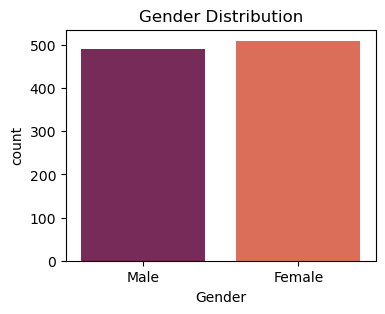

In [32]:
plt.figure(figsize=(4,3))
sns.countplot(x = "Gender",data = df, palette = "rocket", hue="Gender", legend = False)
plt.title("Gender Distribution")
plt.show()

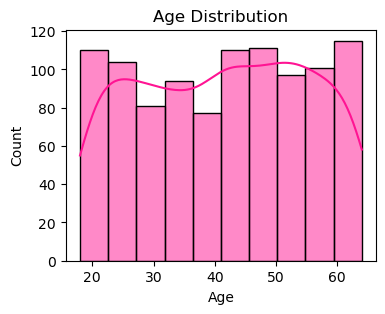

In [34]:
plt.figure(figsize=(4,3))
sns.histplot(df['Age'], bins =10, kde= True, color = "deeppink")
plt.title("Age Distribution")
plt.show()

<Figure size 400x300 with 0 Axes>

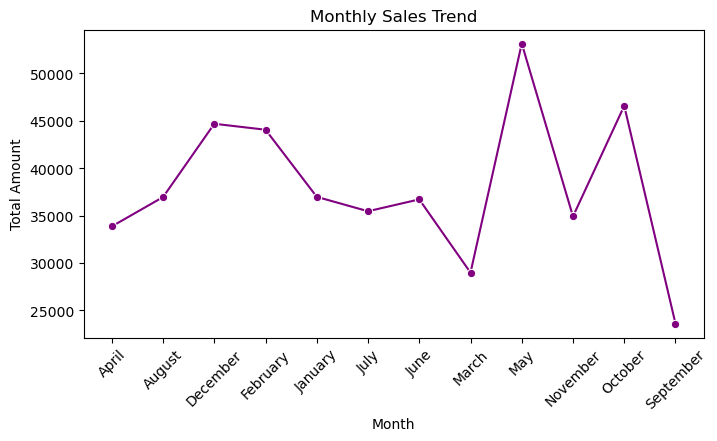

In [39]:
plt.figure(figsize=(4,3))
df['Month'] = df['Date'].dt.month_name()
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
plt.figure(figsize=(8, 4))
sns.lineplot(x='Month', y='Total Amount', data=monthly_sales, marker='o', color='purple')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()


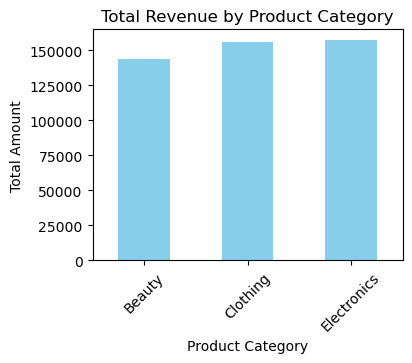

In [52]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
plt.figure(figsize=(4, 3))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

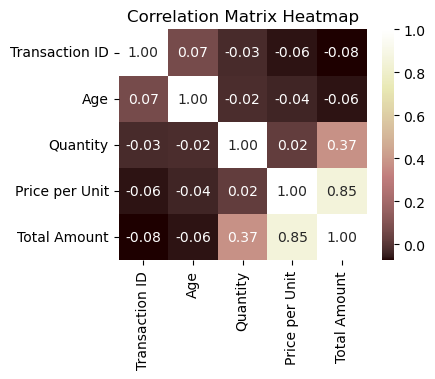

In [54]:
plt.figure(figsize=(4, 3))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='pink', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

### Key Insights

* **The Main Character Month:** May totally wins the award for being the absolute peak era for revenue, while September hit rock bottom with the lowest sales vibes. 
* **Price impact:** The correlation heatmap proves there's a heavy-duty positive vibe (0.85) between `Price per Unit` and `Total Amount`—meaning big-ticket items are literally carrying the team on their back.
* * **Balanced Demographics:** The age and gender breakdown are well-balanced, indicating a diverse and steady customer base across all categories.